# Señales y Sistemas
## Trabajo Práctico Nro. 1


---

### Grupo 10, 2Q2026
Integrantes:
* Ana Negre
* Juan José Medina




In [1]:
pip install numpy matplotlib wget scipy control --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Modelado de señales continuas


### Señales base

Se modelan las señales de escalón, pulso, rampa, aleatoria y senoidal.

Si bien las señales graficadas no son verdaderamente continuas en el sentido matemático, se toma como paso $0.001$ en el rango de $-10$ a $10$; esto resulta en $20000$ puntos para las señales graficadas, lo cual se considera que aporta suficiente granularidad para el análisis realizado.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

step = 0.01
t = np.arange(-10,10,step)
print("Cantidad de puntos:" + str(t.size))
seed = 30 # para reproducibilidad en señal aleatoria

Cantidad de puntos:2000


- Escalón
$$u(t)= \cases{
0\space \text{si}\space t<0 \\
\frac{1}{2} \space \text{si}\space t=0\\
1\space\text{si}\space t>0}$$


Text(0, 0.5, 'u(t)')

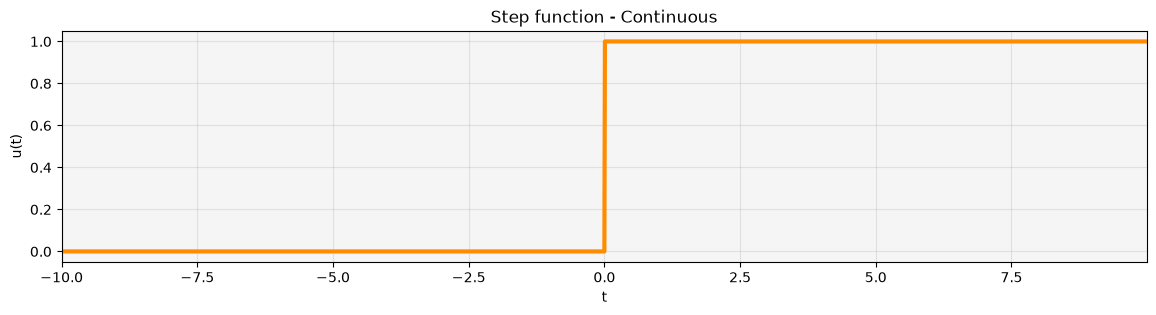

In [3]:
def u(t):
    return np.where(t >= 0, 1, 0)

fig = plt.figure(figsize=(14, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('whitesmoke')

plt.plot(t, u(t), linewidth=3, color="darkorange")
plt.xlim(t.min(), t.max())
plt.grid(True, alpha=0.3)

plt.title('Step function - Continuous')
plt.xlabel('t')
plt.ylabel('u(t)')



- Pulso cuadrado
$$\Pi(t)=\cases{1\space\text{si}\space|t|<\frac{1}{2}\\
\frac{1}{2}\space\text{si}\space t=\frac{1}{2}\\
0\space\text{si}\space |t|>\frac{1}{2}}
$$

Text(0, 0.5, '$\\Pi(t)$')

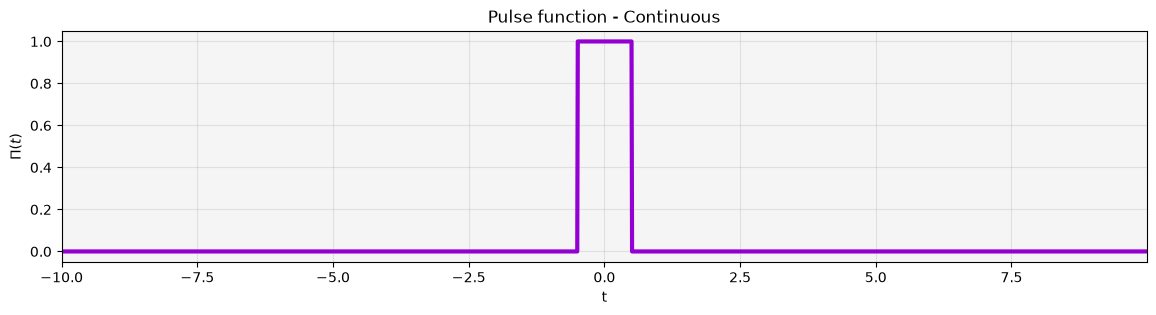

In [4]:
def pulse(t, T=1):
    return np.where(np.abs(t) <= T/2, 1, 0)


fig = plt.figure(figsize=(14, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('whitesmoke')

plt.plot(t, pulse(t), linewidth=3, color="darkviolet")
plt.xlim(t.min(), t.max())
plt.grid(True, alpha=0.3)

plt.title('Pulse function - Continuous')
plt.xlabel('t')
plt.ylabel(r"$\Pi(t)$")
# plt.show() # not necessary in jupyter nt

- Señal rampa
$$r(t)=\cases{0\space\text{si}t<0\\t \space\text{si}\space t\geq 0}$$

Text(0, 0.5, 'r(t)')

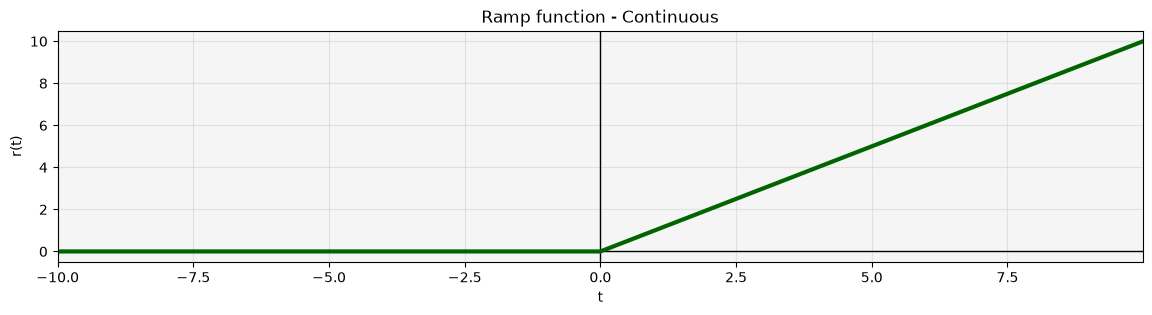

In [5]:
def ramp(t):
    return np.where(t > 0, t, 0)


fig = plt.figure(figsize=(14, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('whitesmoke')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
plt.plot(t, ramp(t), linewidth=3, color="darkgreen")
plt.xlim(t.min(), t.max())
plt.grid(True, alpha=0.3)

plt.title('Ramp function - Continuous')
plt.xlabel('t')
plt.ylabel("r(t)")
# plt.show() # not necessary in jupyter nt


- Señal senoidal
$$sin(t)=A cos(2\pi f_0 t+\phi)$$

Donde $A$ es la amplitud, $f_0$ la frecuencia y $\phi$ la fase de la señal.

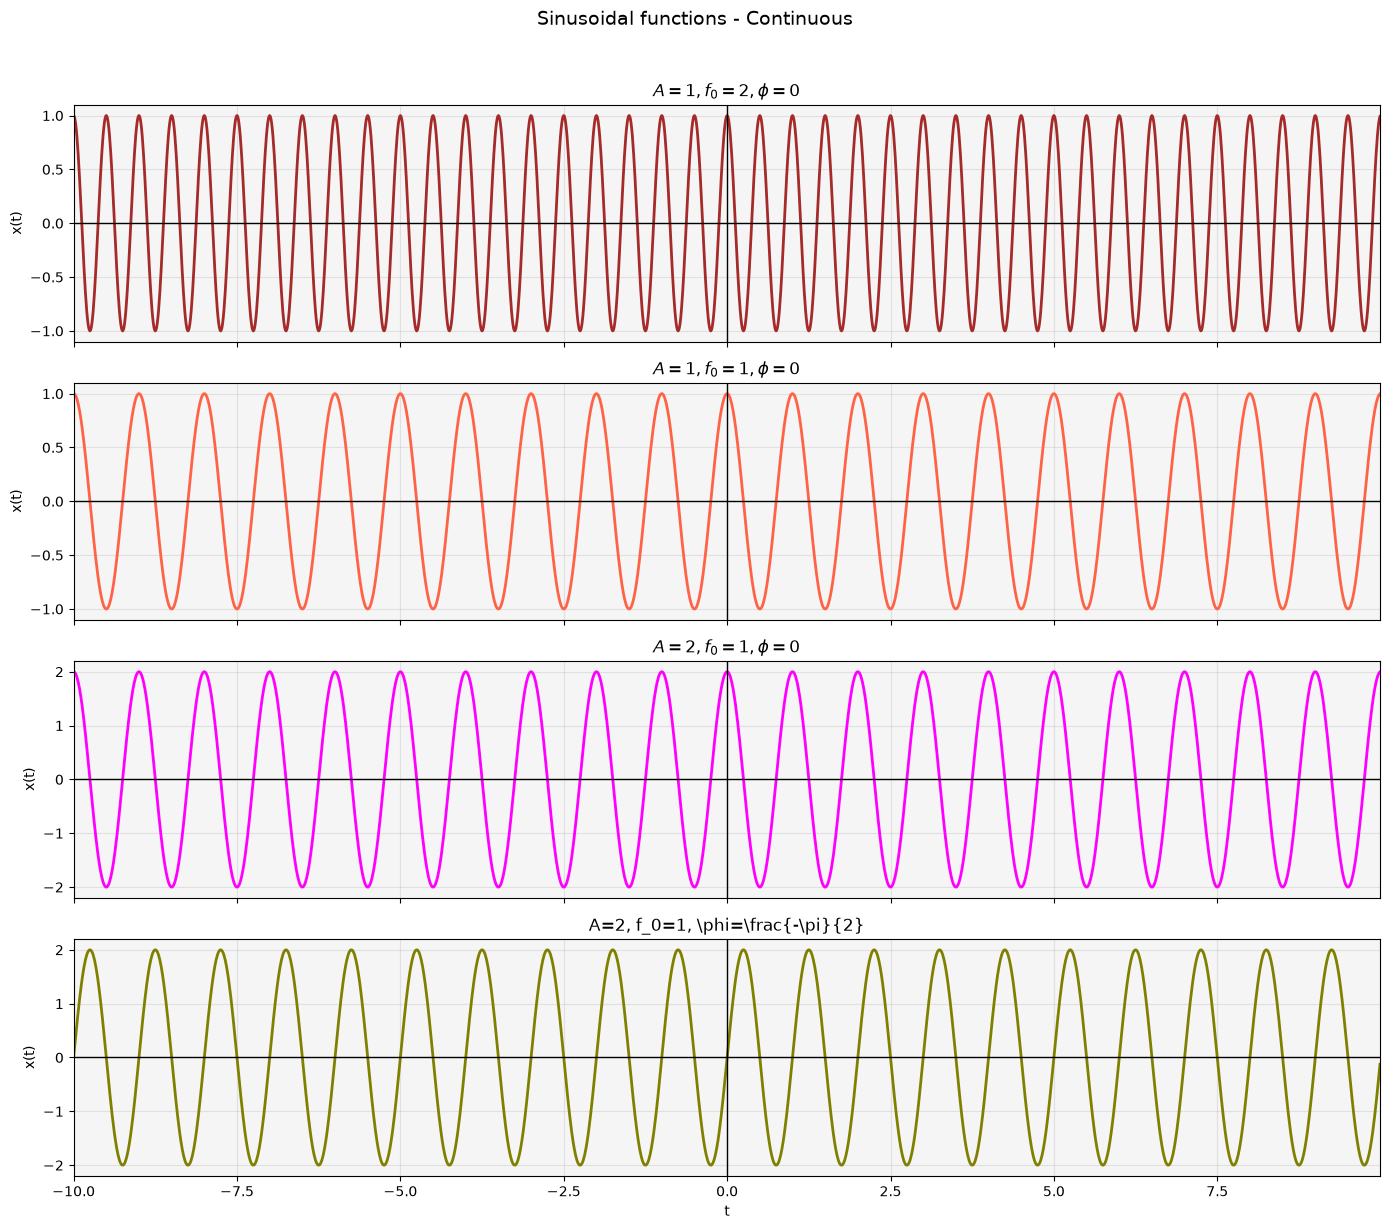

In [6]:
## Se modelan distintas amplitudes y frecuencias para ilustrar las diferencias entre ellas
PHASE = 0
AMPLITUDE = 1
FREQUENCY = 1

def sin(t, amplitude=AMPLITUDE, frequency=FREQUENCY, phase=PHASE):
    return amplitude * np.cos(2 * np.pi * frequency * t + phase)

señales = [
    dict(amplitude=1, frequency=2, phase=0, color="brown", label=r"$A=1, f_0=2, \phi=0$"),
    dict(amplitude=1, frequency=1, phase=0, color="tomato", label=r"$A=1, f_0=1, \phi=0$"),
    dict(amplitude=2, frequency=1, phase=0, color="magenta", label=r"$A=2, f_0=1, \phi=0$"),
    dict(amplitude=2, frequency=1, phase=-np.pi/2, color="olive", label=r"A=2, f_0=1, \phi=\frac{-\pi}{2}"),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), facecolor='white', sharex=True)

for ax, s in zip(axes, señales):
    ax.set_facecolor('whitesmoke')
    ax.plot(t, sin(t, amplitude=s['amplitude'], frequency=s['frequency'], phase=s['phase']),
            linewidth=2, color=s['color'])
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlim(t.min(), t.max())
    ax.grid(True, alpha=0.3)
    ax.set_title(s['label'])
    ax.set_ylabel("x(t)")

axes[-1].set_xlabel('t')
fig.suptitle('Sinusoidal functions - Continuous', fontsize=14, y=1.02)
plt.tight_layout()
# plt.show() # not necessary in jupyter nt



- Señal aleatoria

En este caso, se toman los valores a partir de una distribución uniforme.
$$x(t) \sim \mathcal{U}(-k, k), \quad \forall t,k\in\Re $$


Text(0, 0.5, 'x(t)')

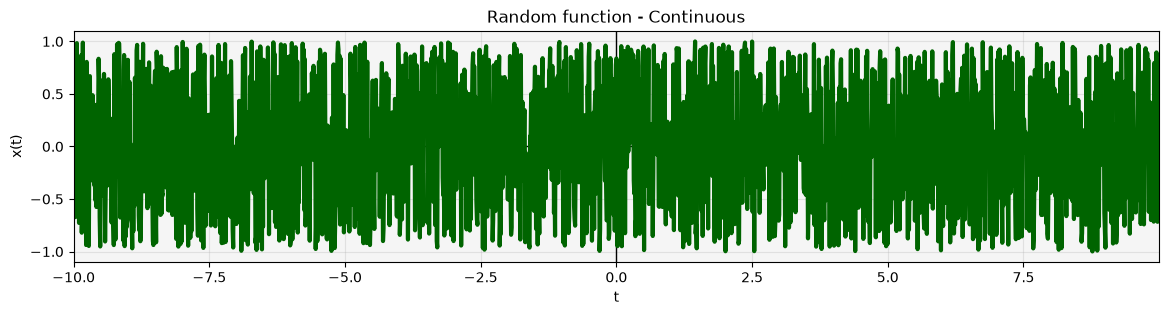

In [7]:
np.random.seed(seed)
k = 1

def random(t,k=1):
    return np.random.uniform(-k, k, len(t))

fig = plt.figure(figsize=(14, 3), facecolor='white')
ax = plt.gca()
ax.set_facecolor('whitesmoke')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
plt.plot(t, random(t), linewidth=3, color="darkgreen")
plt.xlim(t.min(), t.max())
plt.grid(True, alpha=0.3)

plt.title('Random function - Continuous')
plt.xlabel('t')
plt.ylabel("x(t)")
# plt.show() # not necessary in jupyter nt

### Señales reales

Se grafican señales reales de electrocardiograma (ECG) y fonocardiograma (PCG).
[Fuente: Pshysio.net](https://physionet.org/content/ephnogram/1.0.0/MAT/#files-panel)

#### Obtención de archivos
Primero se descargan los archivos deseados utilizando la utility `wget`.
Los archivos se encuentran nombrados del 1 al 69 como `ECGPCG00XX.mat`:

```bash
wget -r -N -c -np https://physionet.org/files/ephnogram/1.0.0/MAT/ECGPCG0010.mat #ejemplo
```

In [8]:
import os

URL = "https://physionet.org/files/ephnogram/1.0.0/MAT/"
FILE = "ECGPCG0010.mat"  # from 00 to 69

target_dir = "/Users/anegre/Documents/ITBA-docs/SeñalesYSistemas/TP1-SeñalesYSistemas-16.68/data/"
os.makedirs(target_dir, exist_ok=True)

filepath = os.path.join(target_dir, FILE)

if not os.path.exists(filepath):
    !wget --no-check-certificate -P {target_dir} {URL}{FILE}

In [9]:
from scipy.io import loadmat

data = loadmat(os.path.join(target_dir, FILE))
print(data.keys())
ecg = data['ECG'].flatten()
pcg = data['PCG'].flatten()
fs = int(data['fs'].flatten()[0])

print(f"ECG length: {len(ecg)}, sampling rate: {fs} Hz")
print(f"ECG duration: {len(ecg)/fs:.1f} seconds")

print(f"PCG length: {len(pcg)}, sampling rate: {fs} Hz")
print(f"PCG duration: {len(pcg)/fs:.1f} seconds")


dict_keys(['__header__', '__version__', '__globals__', 'ECG', 'PCG', 'fs'])
ECG length: 14400000, sampling rate: 8000 Hz
ECG duration: 1800.0 seconds
PCG length: 14400000, sampling rate: 8000 Hz
PCG duration: 1800.0 seconds


#### Gráficos de PCG y ECG
A continuación se grafican las señales correspondientes al ECG y PCG:

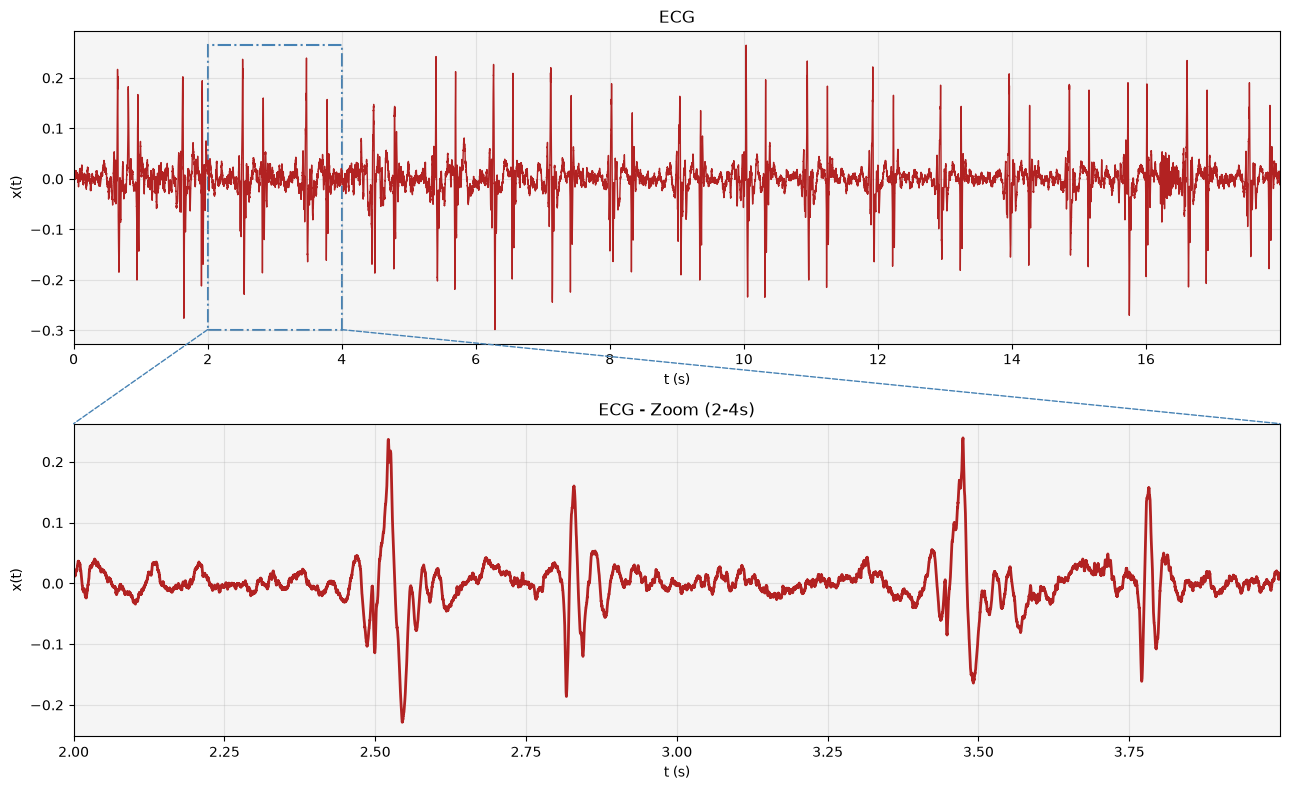

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, ConnectionPatch

t = np.arange(len(ecg)) / fs
window = slice(0, int(fs * 18))
window_zoom = slice(int(fs * 2), int(fs * 4))  # subset de 2s



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), facecolor='white')

# grafico completo
ax1.set_facecolor('whitesmoke')
ax1.plot(t[window], pcg[window], linewidth=1, color="firebrick")
ax1.set_xlim(t[window].min(), t[window].max())
ax1.grid(True, alpha=0.3)
ax1.set_title('ECG')
ax1.set_xlabel('t (s)')
ax1.set_ylabel("x(t)")

# rectángulo para ver el zoom in
t_zoom_start = t[window_zoom].min()
t_zoom_end = t[window_zoom].max()
y_min, y_max = pcg[window].min(), pcg[window].max()
rect = Rectangle(
    (t_zoom_start, y_min), t_zoom_end - t_zoom_start, y_max - y_min,
    linewidth=1.5, edgecolor='steelblue', facecolor='none', linestyle='-.'
)
ax1.add_patch(rect)

# grafico zoom
ax2.set_facecolor('whitesmoke')
ax2.plot(t[window_zoom], pcg[window_zoom], linewidth=2, color="firebrick")
ax2.set_xlim(t[window_zoom].min(), t[window_zoom].max())
ax2.grid(True, alpha=0.3)
ax2.set_title('ECG - Zoom (2-4s)')
ax2.set_xlabel('t (s)')
ax2.set_ylabel("x(t)")
y_zoom_min, y_zoom_max = pcg[window_zoom].min(), pcg[window_zoom].max()

# conectores
con1 = ConnectionPatch(
    xyA=(t_zoom_start, y_min), coordsA=ax1.transData,
    xyB=(0, 1), coordsB=ax2.transAxes,
    color='steelblue', linestyle='--', linewidth=1
)

con2 = ConnectionPatch(
    xyA=(t_zoom_end, y_min), coordsA=ax1.transData,
    xyB=(1, 1), coordsB=ax2.transAxes,
    color='steelblue', linestyle='--', linewidth=1
)
fig.add_artist(con1)
fig.add_artist(con2)


plt.tight_layout()
# plt.show() # not necessary in jupyter nt

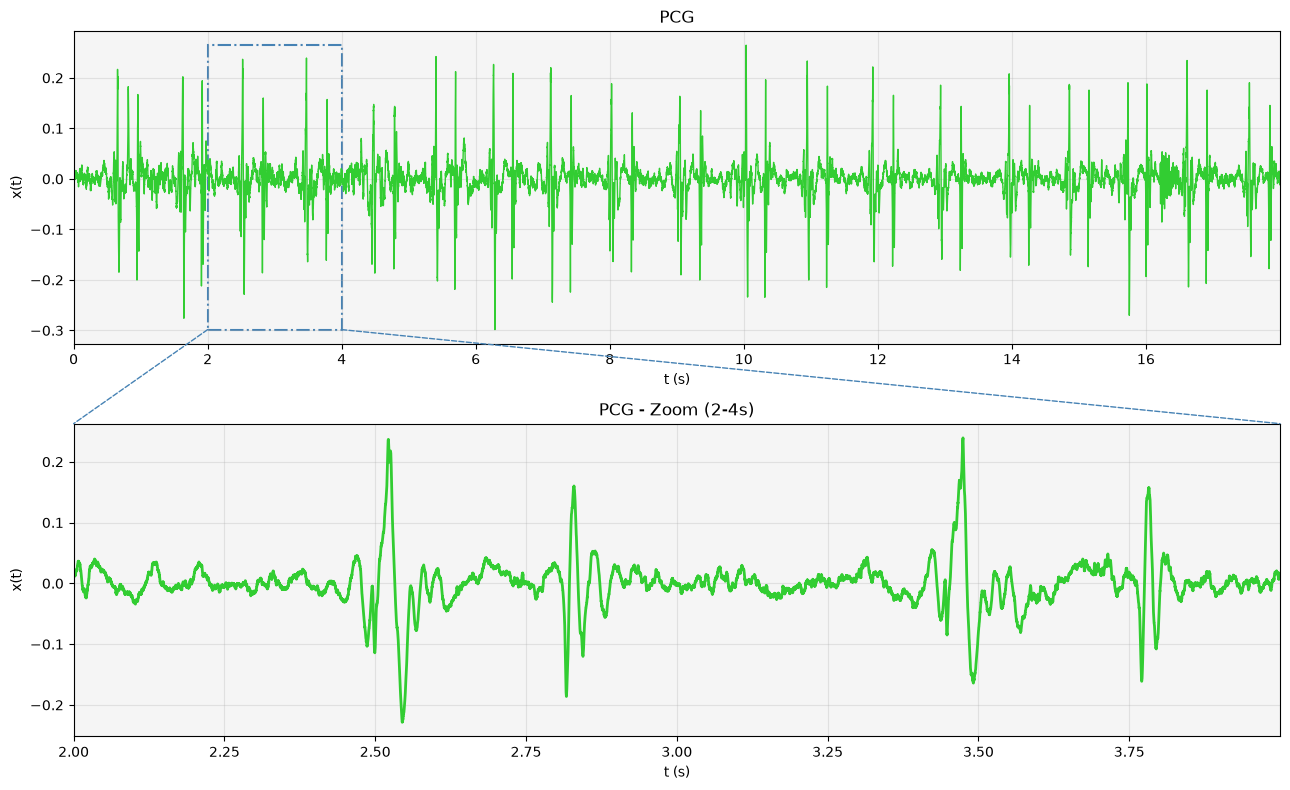

In [11]:
# @title
from matplotlib.patches import Rectangle, ConnectionPatch

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), facecolor='white')

# grafico completo
ax1.set_facecolor('whitesmoke')
ax1.plot(t[window], pcg[window], linewidth=1, color="limegreen")
ax1.set_xlim(t[window].min(), t[window].max())
ax1.grid(True, alpha=0.3)
ax1.set_title('PCG')
ax1.set_xlabel('t (s)')
ax1.set_ylabel("x(t)")

# rectángulo para ver el zoom in
t_zoom_start = t[window_zoom].min()
t_zoom_end = t[window_zoom].max()
y_min, y_max = pcg[window].min(), pcg[window].max()
rect = Rectangle(
    (t_zoom_start, y_min), t_zoom_end - t_zoom_start, y_max - y_min,
    linewidth=1.5, edgecolor='steelblue', facecolor='none', linestyle='-.'
)
ax1.add_patch(rect)

# grafico zoom
ax2.set_facecolor('whitesmoke')
ax2.plot(t[window_zoom], pcg[window_zoom], linewidth=2, color="limegreen")
ax2.set_xlim(t[window_zoom].min(), t[window_zoom].max())
ax2.grid(True, alpha=0.3)
ax2.set_title('PCG - Zoom (2-4s)')
ax2.set_xlabel('t (s)')
ax2.set_ylabel("x(t)")
y_zoom_min, y_zoom_max = pcg[window_zoom].min(), pcg[window_zoom].max()

# conectores
con1 = ConnectionPatch(
    xyA=(t_zoom_start, y_min), coordsA=ax1.transData,
    xyB=(0, 1), coordsB=ax2.transAxes,
    color='steelblue', linestyle='--', linewidth=1
)

con2 = ConnectionPatch(
    xyA=(t_zoom_end, y_min), coordsA=ax1.transData,
    xyB=(1, 1), coordsB=ax2.transAxes,
    color='steelblue', linestyle='--', linewidth=1
)
fig.add_artist(con1)
fig.add_artist(con2)


plt.tight_layout()
# plt.show() # not necessary in jupyter nt

## Modelado de señales discretas

## Comportamiento de circuito eléctrico
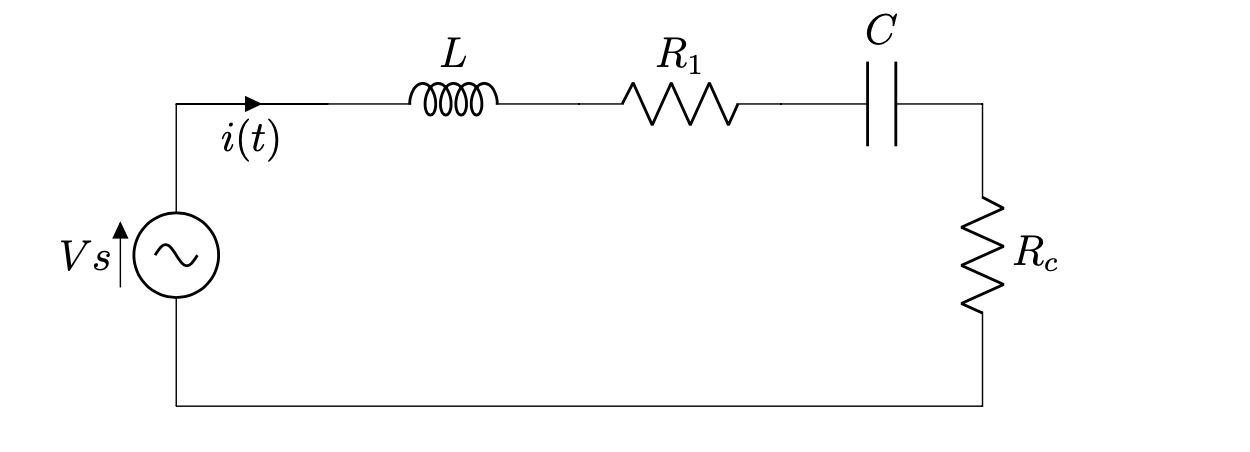

Datos del problema: $L=330\mu H,R_1=4,7 Ω,C=33nF,R_C=56Ω$

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Valores del circuito
L = 330e-6      # H
R1 = 4.7        # ohm
C = 33e-9       # F
Rc = 56         # ohm

### Modelo Matemático

Para el circuito RLC se define como entrada y salida:

$$
x(t)=V_s(t),
\qquad
y(t)=V_{R_c}(t).
$$

Como todos los elementos se encuentran en serie, circula por ellos la misma corriente $i(t)$.
Aplicando la Ley de Kirchhoff de tensiones (KVL):

$$
V_s(t)=V_L(t)+V_{R_1}(t)+V_C(t)+V_{R_c}(t)
$$

Donde las tensiones de cada elemento son:

$$V_L(t)=L\frac{di(t)}{dt}$$
$$V_{R_1}(t)=R_1i(t)$$

$$V_C(t)=\frac{1}{C}\int_{-\infty}^{t}i(\tau)\,d\tau$$
$$V_{R_c}(t)=R_ci(t)=y(t).$$

Reescribiendo la ecuación en función de la entrada/salida, y teniendo en cuenta que $i(t)=\frac{y(t)}{R_c}$, se obtiene:

$$
x(t)=
L\frac{di(t)}{dt}
+(R_1+R_c)i(t)
+\frac{1}{C}\int_{-\infty}^{t}i(\tau)\,d\tau.
$$

$$
x(t)=
\frac{L}{R_c}\frac{dy(t)}{dt}
+\frac{R_1+R_c}{R_c}y(t)
+\frac{1}{R_cC}\int_{-\infty}^{t}y(\tau)\,d\tau.
$$

Finalmente, se puede derivar miembro a miembro respecto del tiempo para reescribir $V_C(t)$ en función de $y(t)$, y luego multiplicar por $R_C*C$:
$$x'(t)=\frac{L}{RC}y''(t)+\frac{R_1+R_C}{R_C}y'(t)+\frac{1}{R_CC}$$
$$
\boxed{
LCy''(t)
+(R_1+R_c)Cy'(t)
+y(t)
=R_cCx'(t)
}
$$

Esta es la ecuación diferencial que modela la relación entre la tensión de entrada
$V_s(t)$ y la tensión de salida sobre $R_c$. Adicionalmente, este sistema $S_c$ descrito por la ecuación diferencial de segundo orden es un sistema LTI.
> [! note] obs!!!! probar linealidad y time invariance?



### Función de transferencia

Por el otro lado, sabemos que, para un sistema LTI descrito por una ecuación diferencial de coficientes constantes y reales de la forma

$$\sum^{n}_{k=0}a_ky^{(k)}(t)=\sum^{m}_{l=0}b_ly^{(l)}(t),$$

la correspondiente función de transferencia, aplicando transformada de Laplace con condiciones iniciales nulas (se asume sistema relajado) está dada por:

$$H(s)=\frac{Y(s)}{X(s)}=\frac{\sum^m_{l=0}b_ls^l}{\sum^n_{k=0}a_ks^k}=\frac{N(s)}{D(s)}$$

En particular, para este tipo de sistema, la función de transferencia queda definida:

$$H(s)=\frac{R_cCs}{LCs^2+(R_1+R_c)Cs+1}$$


$$\boxed{H(s)=\frac{\frac{R_C}{C}s}{s^2+\frac{R_1+R_C}{L}+\frac{1}{LC}}}$$

Utilizando los valores concretos del circuito

$$
L=330\,\mu H,
\qquad
R_1=4.7\,\Omega,
\qquad
C=33\,nF,
\qquad
R_c=56\,\Omega,
$$

se obtiene una función de transferencia de segundo orden cuyo numerador contiene un
cero en $s=0$ y dos polos.

Puede escribirse la función de transferencia en su forma canónica, observando que el numerador se puede expresar como:
$$s^2+2\zeta w_n+w_n^2$$
Con lo cual
$$w_n=\sqrt{\frac{1}{LC}},\qquad \zeta=\frac{R_1+R_c}{2}\sqrt{\frac{C}{L}}$$
Numéricamente,
$$w_n\simeq 3,030 ×10^5 rad/s\Rightarrow f_n\simeq 48,2kHz$$
$$\zeta\simeq 0,304 < 1$$
Con lo cual el sistema es un _filtro pasa banda_ con frecuencia de resonancia cerca de  $48,2 kHz$

Además, observando el comportamiento de manera analítica se tiene que:
$$
H(0)=0,
\qquad
\lim_{f\to\infty}|H(j2\pi f)|=0,
$$

por lo que el circuito atenúa tanto las bajas como las altas frecuencias.

Podemos observar el comportamiento pasa banda en los gráficos de módulo y fase en función de $jw$:



In [13]:
# H(s) = Rc*C*s / (L*C*s^2 + (R1+Rc)*C*s + 1)
num = [Rc*C, 0]
den = [L*C, (R1+Rc)*C, 1]

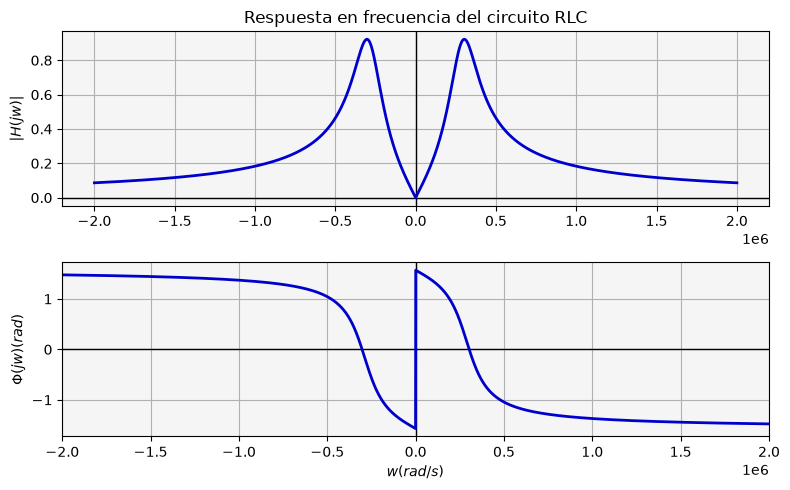

In [14]:
# gráfico de función



w = np.linspace(-2e6, 2e6, 4000)
w, H = signal.freqs(num, den, worN=w)


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))
ax1.set_facecolor('whitesmoke')
ax1.axhline(0, color='black', linewidth=1)
ax1.axvline(0, color='black', linewidth=1)
ax2.set_facecolor('whitesmoke')
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(0, color='black', linewidth=1)
plt.xlim(w.min(), w.max())

ax1.plot(w, np.abs(H),color="mediumblue",linewidth=2.0)
ax1.set_ylabel(r"$|H(jw)|$")
ax1.grid(True)
ax1.set_title('Respuesta en frecuencia del circuito RLC') # se puede evaluar porque la ROC incluye iw

ax2.plot(w, np.angle(H, deg=False),color="mediumblue",linewidth=2.0)
ax2.set_ylabel(r"$\Phi(jw) (rad)$")
ax2.set_xlabel(r"$w (rad/s)$")
ax2.grid(True)

plt.tight_layout()
# plt.show() # not necessary in jupyter nt

Retomando la función de transferencia, puede factorizarse la misma de la forma:
$$G(s)=K\frac{\prod^R_{k=1}(s-\beta_k)}{\prod^P_{l=1}(s-\alpha_l)}$$
Para este sistema, se expresa como:
$$H(s)=\frac{R_C}{L}\frac{s}{(s-p_1)(s-p_2)},
\qquad
p_{1,2}=-\zeta w_n \pm j w_n\sqrt{1-\zeta^2}$$
Como $\zeta < 1$, los polos son complejos conjugados.

Dados los valores numéricos del problema, se pueden visualizar los polos y ceros de la función:


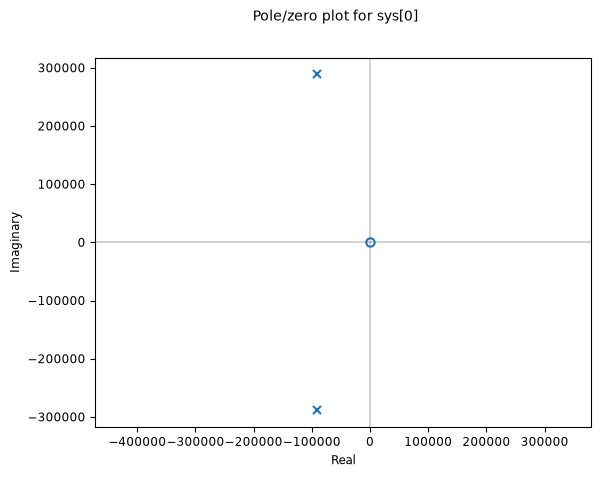

In [15]:
import control as ct
ct.pzmap(ct.tf(num,den))

/var/folders/sm/xqy5108x19l0chm9qtn4r4180000gn/T/ipykernel_12052/2488482442.py:20: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.semilogx(f, mag)
/var/folders/sm/xqy5108x19l0chm9qtn4r4180000gn/T/ipykernel_12052/2488482442.py:32: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.semilogx(f, phase)


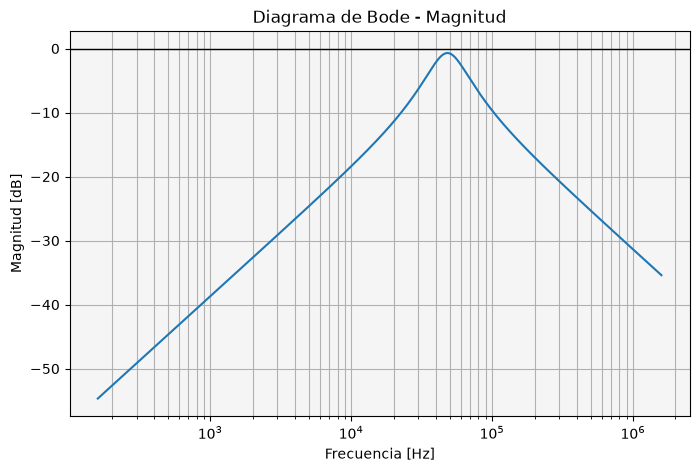

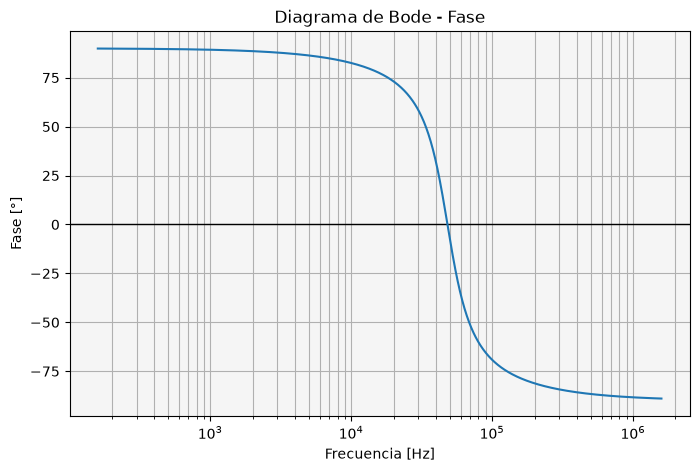

In [16]:
# H(s) = (Rc*C*s) / (L*C*s^2 + (R1+Rc)*C*s + 1)

num = [Rc*C, 0]
den = [L*C, (R1 + Rc)*C, 1]

H = signal.TransferFunction(num, den)

# Bode
w = np.logspace(3, 7, 1000)   # rad/s
w, mag, phase = signal.bode(H, w)

# Pasamos de rad/s a Hz
f = w / (2*np.pi)

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.set_facecolor('whitesmoke')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
plt.semilogx(f, mag)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Diagrama de Bode - Magnitud")
plt.grid(True, which="both")
# plt.show() # not necessary in jupyter nt

plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.set_facecolor('whitesmoke')
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
plt.semilogx(f, phase)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Fase [°]")
plt.title("Diagrama de Bode - Fase")
plt.grid(True, which="both")
# plt.show() # not necessary in jupyter nt

### Interpretación del filtro

A partir del diagrama de Bode se observa que el circuito se comporta como un **filtro pasa-banda**. Las señales de baja frecuencia aparecen fuertemente atenuadas, luego la ganancia aumenta hasta alcanzar un máximo alrededor de la frecuencia de resonancia del circuito, cercana a:

$$
f_0 \approx 48\,\text{kHz}
$$
>[!note] todo poner las frecs de corte

A partir de esa zona, la ganancia vuelve a disminuir para frecuencias más altas.

En consecuencia, el circuito favorece principalmente las componentes de frecuencia cercanas a la frecuencia central y atenúa tanto las componentes de baja frecuencia como las de alta frecuencia. Por lo tanto, si una señal de entrada contiene varias componentes frecuenciales, las cercanas a la banda de paso aparecerán con mayor amplitud en la salida, mientras que las que estén alejadas de esa zona serán reducidas.

El gráfico de fase muestra además que el circuito introduce un desfase dependiente de la frecuencia: las componentes de baja frecuencia presentan una fase cercana a \(+90), alrededor de la frecuencia central el desfase pasa aproximadamente por \(0), y a frecuencias altas tiende a \(-90).

### Simulacion con espectro de entrada y salida


Frecuencia de resonancia: 48.23 kHz


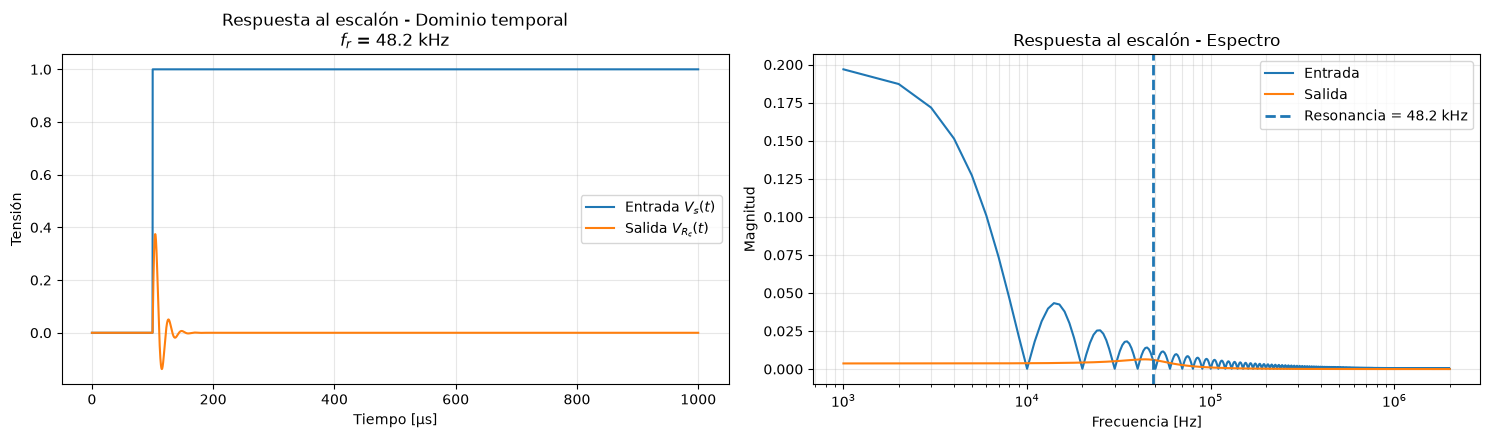

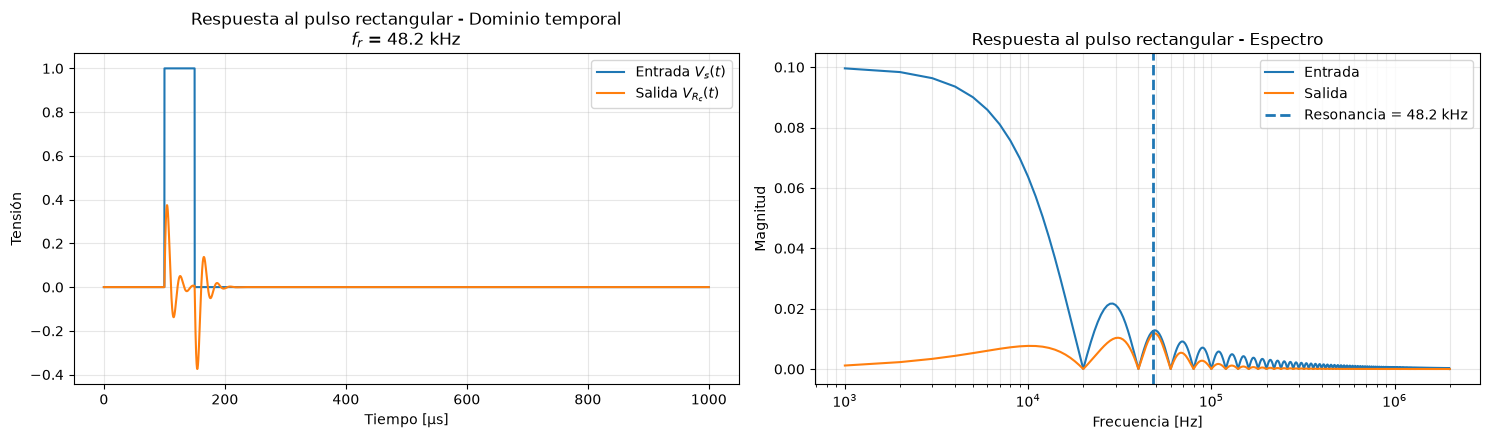

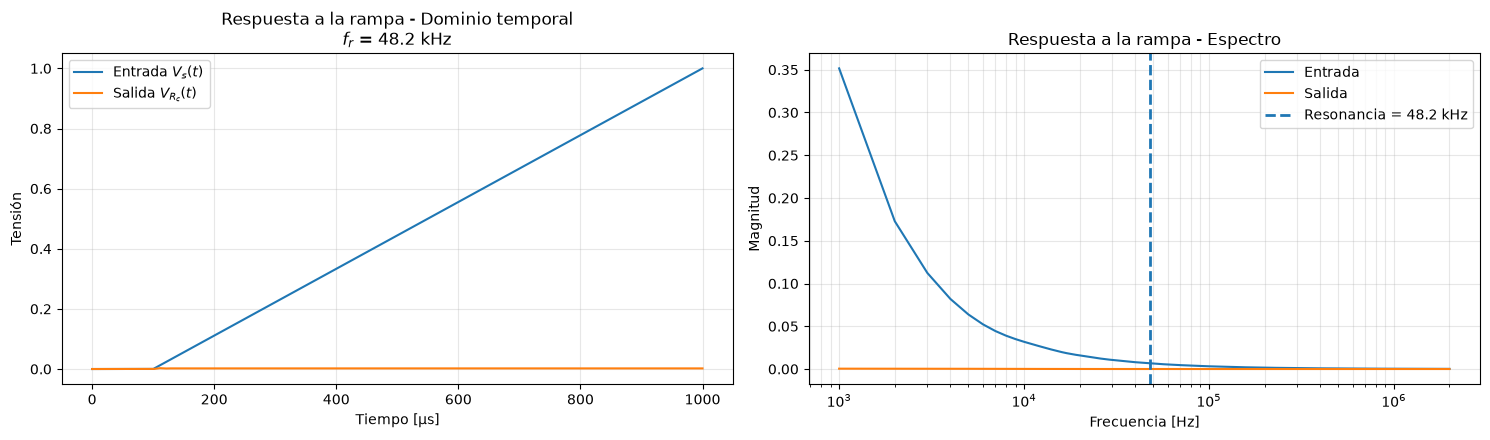

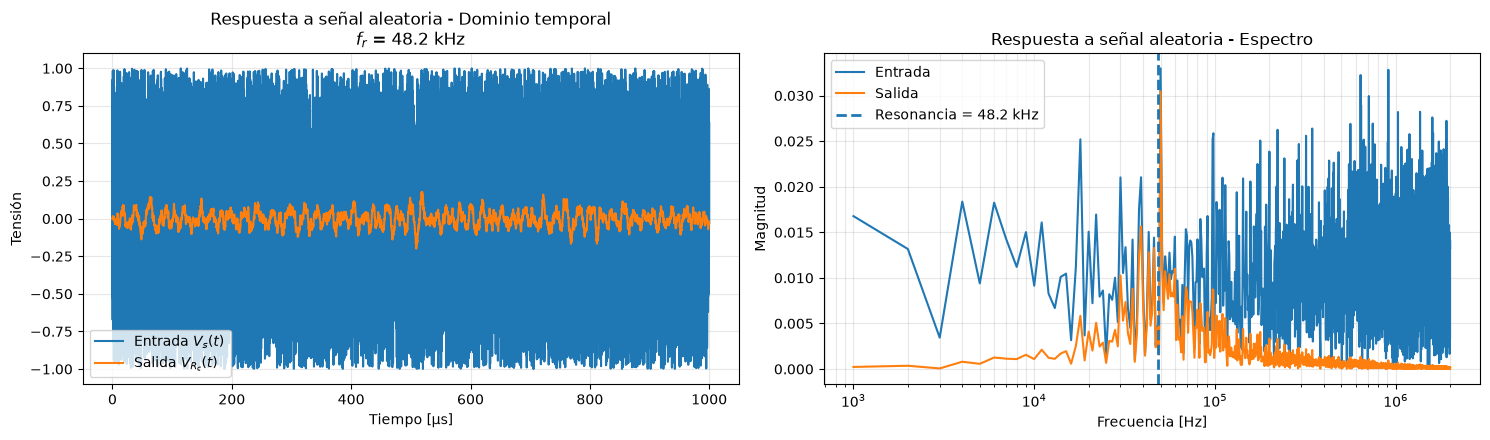

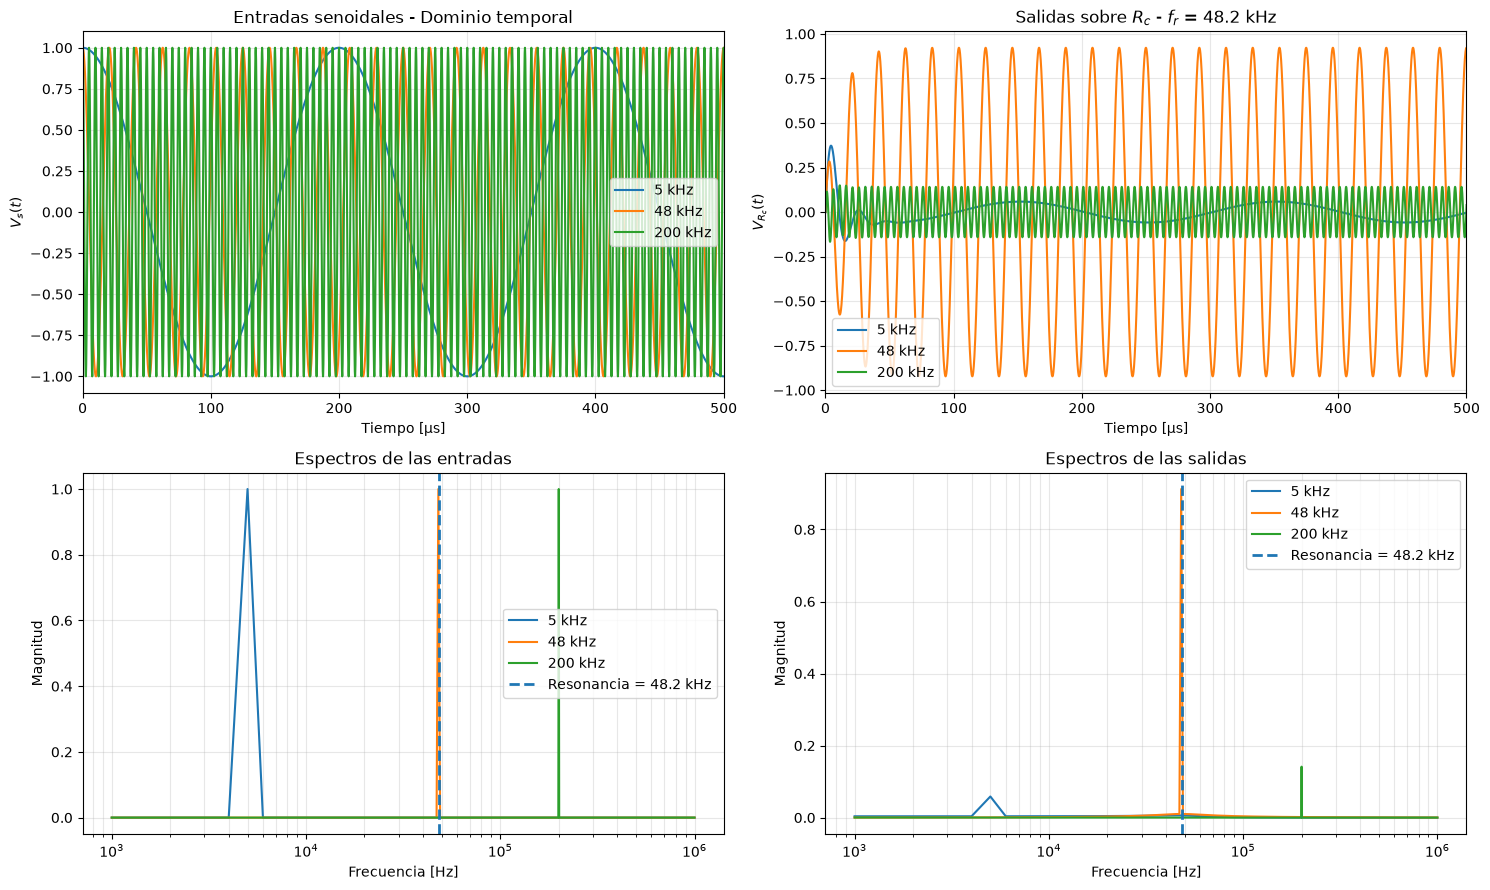

In [17]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# ============================================================
# 1. CIRCUITO RLC
# ============================================================

L = 330e-6      # H
R1 = 4.7        # ohm
C = 33e-9       # F
Rc = 56         # ohm

# H(s) = Rc*C*s / (L*C*s^2 + (R1+Rc)*C*s + 1)

num = [Rc*C, 0]
den = [L*C, (R1 + Rc)*C, 1]

H = signal.TransferFunction(num, den)

# Frecuencia de resonancia
f0 = 1 / (2*np.pi*np.sqrt(L*C))

print(f"Frecuencia de resonancia: {f0/1000:.2f} kHz")


# ============================================================
# 2. VECTOR DE TIEMPO PARA LA SIMULACIÓN
# ============================================================

dt = 0.1e-6                    # 0.1 microsegundos
t_rlc = np.arange(0, 1e-3, dt) # 1 ms


# ============================================================
# 3. FUNCIONES AUXILIARES
# ============================================================

def respuesta_circuito(x):
    """Calcula la tensión de salida sobre Rc."""
    tout, y, _ = signal.lsim(H, U=x, T=t_rlc)
    return tout, y


def espectro(x):
    """Calcula el espectro de magnitud de una señal."""
    N = len(x)

    f = np.fft.rfftfreq(N, dt)
    X = np.fft.rfft(x)

    magnitud = 2 * np.abs(X) / N

    return f, magnitud


def marcar_resonancia(ax):
    """Agrega la frecuencia de resonancia a un gráfico espectral."""
    ax.axvline(
        f0,
        linestyle="--",
        linewidth=2,
        label=f"Resonancia = {f0/1000:.1f} kHz"
    )


def analizar_senal(x, nombre):
    """
    Grafica entrada y salida:
    - dominio temporal
    - dominio frecuencial
    """

    tout, y = respuesta_circuito(x)

    f, X = espectro(x)
    _, Y = espectro(y)

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

    # -------------------------------
    # Dominio temporal
    # -------------------------------

    axes[0].plot(tout * 1e6, x, label="Entrada $V_s(t)$")
    axes[0].plot(tout * 1e6, y, label="Salida $V_{R_c}(t)$")

    axes[0].set_title(
        f"{nombre} - Dominio temporal\n"
        f"$f_r$ = {f0/1000:.1f} kHz"
    )

    axes[0].set_xlabel("Tiempo [µs]")
    axes[0].set_ylabel("Tensión")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # -------------------------------
    # Dominio frecuencial
    # -------------------------------

    mask = (f > 0) & (f <= 2e6)

    axes[1].semilogx(
        f[mask],
        X[mask],
        label="Entrada"
    )

    axes[1].semilogx(
        f[mask],
        Y[mask],
        label="Salida"
    )

    marcar_resonancia(axes[1])

    axes[1].set_title(f"{nombre} - Espectro")
    axes[1].set_xlabel("Frecuencia [Hz]")
    axes[1].set_ylabel("Magnitud")
    axes[1].grid(True, which="both", alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    # plt.show() # not necessary in jupyter nt

    return y


# ============================================================
# 4. ESCALÓN
# ============================================================

entrada_step = np.where(t_rlc >= 100e-6, 1, 0)

salida_step = analizar_senal(
    entrada_step,
    "Respuesta al escalón"
)


# ============================================================
# 5. PULSO RECTANGULAR
# ============================================================

entrada_pulso = np.where(
    (t_rlc >= 100e-6) & (t_rlc <= 150e-6),
    1,
    0
)

salida_pulso = analizar_senal(
    entrada_pulso,
    "Respuesta al pulso rectangular"
)


# ============================================================
# 6. RAMPA
# ============================================================

entrada_rampa = np.where(
    t_rlc >= 100e-6,
    (t_rlc - 100e-6) / (t_rlc.max() - 100e-6),
    0
)

salida_rampa = analizar_senal(
    entrada_rampa,
    "Respuesta a la rampa"
)


# ============================================================
# 7. SEÑAL ALEATORIA
# ============================================================

np.random.seed(30)

entrada_random = np.random.uniform(
    -1,
    1,
    len(t_rlc)
)

salida_random = analizar_senal(
    entrada_random,
    "Respuesta a señal aleatoria"
)


# ============================================================
# 8. TRES SENOIDALES JUNTAS
# ============================================================

frecuencias = [
    5e3,       # frecuencia baja
    48e3,      # cercana a resonancia
    200e3      # frecuencia alta
]

nombres = [
    "5 kHz",
    "48 kHz",
    "200 kHz"
]

entradas_seno = []
salidas_seno = []

for f_seno in frecuencias:

    x = np.cos(2*np.pi*f_seno*t_rlc)

    _, y = respuesta_circuito(x)

    entradas_seno.append(x)
    salidas_seno.append(y)


# ============================================================
# 9. GRÁFICOS COMPARATIVOS DE LAS TRES SENOIDALES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 9))


# ------------------------------------------------------------
# Entradas en tiempo
# ------------------------------------------------------------

for x, nombre in zip(entradas_seno, nombres):

    axes[0, 0].plot(
        t_rlc * 1e6,
        x,
        label=nombre
    )

axes[0, 0].set_xlim(0, 500)

axes[0, 0].set_title(
    "Entradas senoidales - Dominio temporal"
)

axes[0, 0].set_xlabel("Tiempo [µs]")
axes[0, 0].set_ylabel("$V_s(t)$")

axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()


# ------------------------------------------------------------
# Salidas en tiempo
# ------------------------------------------------------------

for y, nombre in zip(salidas_seno, nombres):

    axes[0, 1].plot(
        t_rlc * 1e6,
        y,
        label=nombre
    )

axes[0, 1].set_xlim(0, 500)

axes[0, 1].set_title(
    f"Salidas sobre $R_c$ - $f_r$ = {f0/1000:.1f} kHz"
)

axes[0, 1].set_xlabel("Tiempo [µs]")
axes[0, 1].set_ylabel("$V_{R_c}(t)$")

axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()


# ------------------------------------------------------------
# Espectros de entrada
# ------------------------------------------------------------

for x, nombre in zip(entradas_seno, nombres):

    f, X = espectro(x)

    mask = (f > 0) & (f <= 1e6)

    axes[1, 0].semilogx(
        f[mask],
        X[mask],
        label=nombre
    )

marcar_resonancia(axes[1, 0])

axes[1, 0].set_title(
    "Espectros de las entradas"
)

axes[1, 0].set_xlabel("Frecuencia [Hz]")
axes[1, 0].set_ylabel("Magnitud")

axes[1, 0].grid(True, which="both", alpha=0.3)
axes[1, 0].legend()


# ------------------------------------------------------------
# Espectros de salida
# ------------------------------------------------------------

for y, nombre in zip(salidas_seno, nombres):

    f, Y = espectro(y)

    mask = (f > 0) & (f <= 1e6)

    axes[1, 1].semilogx(
        f[mask],
        Y[mask],
        label=nombre
    )

marcar_resonancia(axes[1, 1])

axes[1, 1].set_title(
    "Espectros de las salidas"
)

axes[1, 1].set_xlabel("Frecuencia [Hz]")
axes[1, 1].set_ylabel("Magnitud")

axes[1, 1].grid(True, which="both", alpha=0.3)
axes[1, 1].legend()


plt.tight_layout()
#  # not necessary in jupyter nt

## Análisis de las respuestas en tiempo y frecuencia

Para analizar el comportamiento del circuito se estudian tanto la señal de entrada
\(V_s(t)\) como la tensión de salida sobre la resistencia \(V_{R_c}(t)\).

En el dominio frecuencial ambas se relacionan mediante:

$$
Y(f)=H(j2\pi f)X(f),
$$

donde \(X(f)\) es la Transformada de Fourier de la entrada, \(Y(f)\) la de la salida y

$$
H(j2\pi f)=
\frac{j2\pi f R_c C}
{1-(2\pi f)^2LC+j2\pi f(R_1+R_c)C}.
$$

El circuito presenta una frecuencia de resonancia dada por:

$$
f_r=\frac{1}{2\pi\sqrt{LC}}
\approx48.2\,\text{kHz}.
$$

En esta frecuencia se compensan los efectos reactivos del inductor y del capacitor.
La ganancia máxima no llega exactamente a uno debido a la presencia de \(R_1\):

$$
|H(f_r)|=
\frac{R_c}{R_1+R_c}
=
\frac{56}{56+4.7}
\approx0.923.
$$

Por lo tanto, las componentes próximas a \(48.2\,\text{kHz}\) son las que sufren
menor atenuación, mientras que las frecuencias considerablemente menores o mayores
son atenuadas.

---

### Respuesta al escalón

Para un escalón ideal:

$$
u(t),
$$

su Transformada de Fourier puede escribirse como:

$$
\mathcal{F}\{u(t)\}
=
\frac{1}{2}\delta(f)
+
\frac{1}{j2\pi f}.
$$

Si el escalón comienza en un instante \(t_s\),

$$
x(t)=u(t-t_s),
$$

el corrimiento temporal introduce un factor exponencial:

$$
X(f)
=
e^{-j2\pi ft_s}
\left[
\frac{1}{2}\delta(f)
+
\frac{1}{j2\pi f}
\right].
$$

Sin embargo, la FFT numérica no observa una señal de duración infinita. En la simulación,
el escalón comienza en:

$$
t_s=100\,\mu s
$$

y el registro termina en:

$$
T_{\text{obs}}=1\,ms.
$$

Por lo tanto, desde el punto de vista numérico, la señal observada equivale a:

$$
x_{\text{obs}}(t)
=
u(t-t_s)-u(t-T_{\text{obs}}),
$$

es decir, un pulso rectangular de duración:

$$
D=T_{\text{obs}}-t_s=900\,\mu s.
$$

Su Transformada de Fourier tiene forma:

$$
X_{\text{obs}}(f)
=
D\,\operatorname{sinc}(Df)
e^{-j2\pi f t_c},
$$

donde \(t_c\) es el centro temporal del intervalo en el que la señal vale uno.

Esto explica por qué el espectro numérico del escalón presenta lóbulos con forma de sinc
y se parece al espectro de un pulso rectangular.

No se está observando la Transformada de Fourier del escalón ideal infinito, sino la
Transformada de Fourier de una versión truncada por la ventana temporal de simulación.

En el dominio temporal se observa que el cambio brusco del escalón excita al circuito,
produciendo una oscilación transitoria próxima a su frecuencia natural. Una vez que
la entrada permanece constante, la salida tiende nuevamente a cero debido a que el
circuito pasa-banda atenúa fuertemente la componente continua \(f=0\).

---

### Respuesta al pulso rectangular

Un pulso rectangular de duración \(D\), centrado en \(t_c\), puede escribirse como:

$$
x(t)=
\Pi\left(\frac{t-t_c}{D}\right).
$$

Su Transformada de Fourier es:

$$
X(f)
=
D\,\operatorname{sinc}(Df)
e^{-j2\pi ft_c}.
$$

En la simulación el pulso tiene una duración aproximada de:

$$
D=50\,\mu s.
$$

Por esta razón su espectro presenta la forma característica de una sinc, con una
componente importante a bajas frecuencias y una sucesión de lóbulos y ceros.

La salida del circuito se obtiene mediante:

$$
Y(f)=H(j2\pi f)X(f).
$$

Por lo tanto, aunque el pulso contiene un rango amplio de frecuencias, las componentes
próximas a la banda de paso son transmitidas en mayor proporción.

En el dominio temporal se observa una oscilación cuando aparece el pulso y otra cuando
desaparece. Esto puede entenderse escribiendo el pulso como la diferencia entre dos
escalones:

$$
x(t)=u(t-t_1)-u(t-t_2).
$$

Cada cambio brusco excita la respuesta transitoria del circuito.

La similitud entre el espectro del pulso y el espectro numérico del escalón se debe a que,
al trabajar con una ventana temporal finita, el escalón simulado también se convierte
efectivamente en una señal rectangular de duración finita.

---

### Respuesta a la rampa

La rampa utilizada tiene la forma general:

$$
r(t)=t\,u(t).
$$

Su contenido espectral se encuentra fuertemente concentrado en bajas frecuencias.
Esto puede comprenderse observando que la rampa varía lentamente en el tiempo y que
su pendiente es constante.

En la simulación, además, la rampa está truncada y normalizada dentro del intervalo de
observación. Por lo tanto, el espectro obtenido mediante FFT corresponde a esta versión
finita de la rampa.

Como el circuito es pasa-banda y atenúa fuertemente las componentes de baja frecuencia,
la tensión de salida sobre \(R_c\) resulta muy pequeña.

Para frecuencias bajas puede aproximarse la función de transferencia como:

$$
H(j2\pi f)\approx j2\pi fR_cC.
$$

Esto significa que, en esta zona de frecuencias, el circuito presenta aproximadamente
un comportamiento derivativo:

$$
y(t)\approx R_cC\frac{dx(t)}{dt}.
$$

Como la derivada de una rampa es constante y la pendiente utilizada en la simulación es
pequeña, la salida obtenida también presenta una amplitud reducida.

---

### Respuesta a señales senoidales

Para una señal senoidal:

$$
x(t)=A\cos(2\pi f_0t+\phi),
$$

su Transformada de Fourier es:

$$
X(f)
=
\frac{A}{2}e^{j\phi}\delta(f-f_0)
+
\frac{A}{2}e^{-j\phi}\delta(f+f_0).
$$

Por lo tanto, una senoide ideal contiene únicamente dos componentes frecuenciales,
ubicadas en:

$$
f=\pm f_0.
$$

Como en los gráficos se representa solamente el espectro positivo de la FFT, se observa
un único pico en \(f=f_0\).

Al atravesar el circuito:

$$
Y(f)=H(j2\pi f)X(f),
$$

por lo que la frecuencia de la senoide no cambia. Lo que cambia es su amplitud y su fase:

$$
y(t)=
A|H(j2\pi f_0)|
\cos\left(
2\pi f_0t+\phi+\angle H(j2\pi f_0)
\right).
$$

Se analizaron tres frecuencias: \(5\,\text{kHz}\), \(48\,\text{kHz}\) y
\(200\,\text{kHz}\).

Para \(5\,\text{kHz}\):

$$
|H(5\,\text{kHz})|\approx0.0586,
$$

lo que equivale aproximadamente a:

$$
20\log_{10}(0.0586)\approx-24.6\,\text{dB}.
$$

La señal queda fuertemente atenuada por encontrarse muy por debajo de la frecuencia
de resonancia.

Para \(48\,\text{kHz}\):

$$
|H(48\,\text{kHz})|\approx0.922,
$$

equivalente aproximadamente a:

$$
20\log_{10}(0.922)\approx-0.70\,\text{dB}.
$$

Esta frecuencia se encuentra prácticamente sobre la resonancia del circuito, por lo que
la señal aparece en la salida con una amplitud cercana a la de entrada.

Para \(200\,\text{kHz}\):

$$
|H(200\,\text{kHz})|\approx0.142,
$$

equivalente aproximadamente a:

$$
20\log_{10}(0.142)\approx-17.0\,\text{dB}.
$$

Esta componente vuelve a ser atenuada por encontrarse por encima de la banda de paso.

Los resultados coinciden directamente con el comportamiento observado en el diagrama
de Bode: el circuito deja pasar preferentemente las frecuencias cercanas a
\(48.2\,\text{kHz}\) y atenúa tanto las frecuencias bajas como las altas.

---

### Respuesta a la señal aleatoria

La señal aleatoria utilizada está formada por valores distribuidos alrededor de cero y
contiene componentes en un rango amplio de frecuencias.

En una señal aleatoria ideal con características similares a ruido blanco, la potencia se
encuentra distribuida aproximadamente sobre un amplio intervalo de frecuencias.

La FFT de una realización finita no resulta perfectamente uniforme, por lo que el espectro
de entrada presenta fluctuaciones.

Al atravesar el circuito:

$$
Y(f)=H(j2\pi f)X(f).
$$

Esto significa que cada componente frecuencial presente en la entrada es multiplicada por
el valor de la función de transferencia correspondiente a esa frecuencia.

Las frecuencias alejadas de la banda de paso son fuertemente reducidas, mientras que las
componentes próximas a:

$$
f_r\approx48.2\,\text{kHz}
$$

son transmitidas con mayor amplitud.

Esto se observa claramente en el espectro de salida, donde aparece una concentración de
componentes alrededor de la frecuencia de resonancia.

En el dominio temporal, la señal de salida presenta una amplitud mucho menor que la señal
aleatoria original y muestra un comportamiento más oscilatorio, asociado principalmente
a las frecuencias que el circuito permite atravesar.

---

### Conclusión

Todas las simulaciones pueden interpretarse mediante la misma relación fundamental:

$$
\boxed{
Y(f)=H(j2\pi f)X(f)
}
$$

El circuito actúa sobre cada componente frecuencial de la señal de entrada de manera
independiente.

Las componentes cercanas a:

$$
f_r\approx48.2\,\text{kHz}
$$

presentan la menor atenuación, mientras que las componentes de baja y alta frecuencia son
reducidas.

Los resultados obtenidos en el dominio temporal, los espectros calculados mediante FFT
y el diagrama de Bode representan tres formas diferentes de observar el mismo
comportamiento pasa-banda del circuito.